## Attempt to map between global and local lens maps

Firstly, we set up teh julia environment and necessary packages.

In [1]:
import Pkg: activate
activate(joinpath(pwd(), ".."))
using Optical_Drift_Effects
Threads.nthreads()

  Activating project at `~/Documents/Optical_Drift_Effects`


6

In [2]:
using LinearAlgebra
using StaticArrays
using Plots
using Printf

# Lens set-up

In [3]:
θE = 1.0
q = 0.8
φ=0.0

lens = SIE(θE, q, φ )

SIE(1.0, 0.8, 0.0, 0.0, 0.0, 1.0e-6, 1.0e-12)

# Source set-up

In [4]:
β0 = SVector{2,Float64}(0.0, 0.1) # Source position in the source plane (βx, βy)
Rs = 0.01 # Effective radius of the Sersic profile

src = SersicSource(
    I0=1.0,
    Re=Rs,
    n=2.0, # Sersic index (n=1 exponential, n=4 de Vaucouleurs)
    q=0.7, #axis ratio (1.0 = circular)
    ϕ=0.0, # position angle (radians, for elliptical sources)
    β0=β0,
    normalize=:none 
)

SersicSource(1.0, 0.01, 2.0, 0.7, 0.0, [0.0, 0.1], 1.0e-12, :none, 1.0)

# Grid set-up

In [5]:
os = 10          # oversampling factor (pixels per output pixel, per axis)

Nx_pix, Ny_pix = 50, 50                 # desired output (pixelated) resolution
Nx_hi,  Ny_hi  = os * Nx_pix, os * Ny_pix  # high-res ray grid

xmin, xmax = -2.2, 2.2
ymin, ymax = -2.2, 2.2

# High-res ray grid 
xs_hi = range(xmin, xmax; length=Nx_hi)
ys_hi = range(ymin, ymax; length=Ny_hi)

# Output pixel centres (for plot axes)
xs_pix = range(xmin, xmax; length=Nx_pix)
ys_pix = range(ymin, ymax; length=Ny_pix)


-2.2:0.08979591836734693:2.2

# Critical and Caustic Curves

In [6]:
critical_polylines = critical_curves(lens, xs_hi, ys_hi)
caustic_polylines = caustic_curves(lens, critical_polylines)

1-element Vector{Vector{SVector{2, Float64}}}:
 [[0.056116463743230094, -0.03882739197728402], [0.05562360043275849, -0.03922722915860244], [0.05373040951546604, -0.04078709021073057], [0.05368101008956472, -0.04082830920316993], [0.051880702527164924, -0.04234884709480824], [0.05123692206834729, -0.04290139305897345], [0.05006643431444313, -0.043918169302567645], [0.04877791252110919, -0.04505600911910668], [0.04828651034906306, -0.04549516398142839], [0.04654402385100109, -0.04707618905343214]  …  [0.06566782156746198, -0.03155714673577137], [0.06563995309896842, -0.03157710023163052], [0.06356163787619273, -0.03308519935385146], [0.06331118848960893, -0.03326963374584069], [0.061521472432452096, -0.03460482530447928], [0.06093331468699115, -0.03505028988382686], [0.05951878585171311, -0.03613541738651127], [0.05853465593488927, -0.03690202793380715], [0.057553048477521296, -0.03767636819767495], [0.056116463743230094, -0.03882739197728402]]

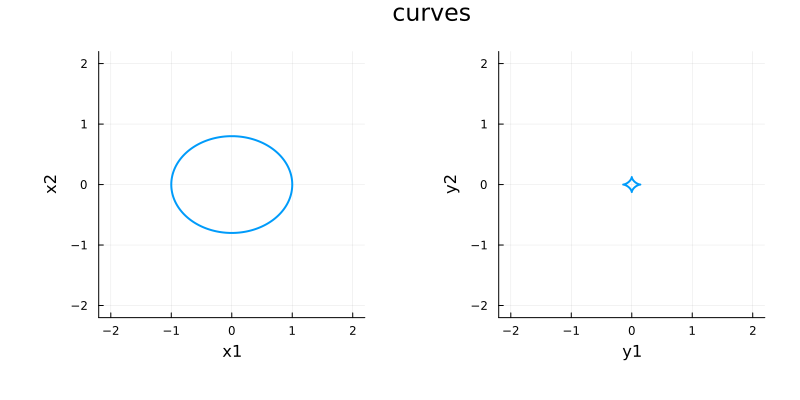

In [7]:
p_src = plot(; aspect_ratio=:equal,
    xlims=(xmin, xmax), ylims=(ymin, ymax),
    xlabel="y1", ylabel="y2",
    legend=false
)

p_lens = plot(; aspect_ratio=:equal,
    xlims=(xmin, xmax), ylims=(ymin, ymax),
    xlabel="x1", ylabel="x2",
    legend=false
)

for poly in caustic_polylines
    plot!(p_src, first.(poly), last.(poly); lw=2)
end

for poly in critical_polylines
    plot!(p_lens, first.(poly), last.(poly); lw=2)
end

whole_plot = plot(p_lens, p_src; layout=(1,2), plot_title="curves", size=(800, 400), left_margin=12Plots.mm, right_margin=6Plots.mm,
    top_margin=6Plots.mm,   bottom_margin=12Plots.mm)


# Coordinate mapping

In [8]:
# -----------------------------------------------------------------------
# Fold / Cusp classification of caustic/critical curves
#
# At a critical point x_c where det(A) = 0, the caustic velocity is
#   dy/dt = A(x_c) * dx/dt
# Let v = null eigenvector of A, and t = tangent to the critical curve.
#
#   Fold: t NOT parallel to v  -->  dy/dt != 0
#   Cusp: t     parallel to v  -->  dy/dt  = 0
#
# Key insight: the null eigenvector of A in the global frame is exactly the
# second row of M (the degenerate local-frame axis mapped back to global).
# This avoids needing eigen() and sidesteps sign-convention issues in
# deflection_jacobian.
# -----------------------------------------------------------------------

all_labels = [classify_caustic_polyline(poly, lens) for poly in critical_polylines]

for (k, labels) in enumerate(all_labels)
    println("Polyline ", k, ": ", count(==(:fold), labels), " fold, ",
            count(==(:cusp), labels), " cusp")
end



Polyline 1: 609 fold, 208 cusp


In [9]:
# Plot the caustic coloured by type: fold = blue, cusp = red
p_class = plot(; aspect_ratio=:equal, xlims=(0.5 *xmin, 0.5 *xmax), ylims=(0.5 * ymin, 0.5 * ymax),
               xlabel="y1", ylabel="y2", title="Caustic: fold (blue) / cusp (red)",
               size=(800,800), legend=false)

for (k, (crit_poly, caust_poly)) in enumerate(zip(critical_polylines, caustic_polylines))
    labels = all_labels[k]
    i_fold = findall(==(:fold), labels)
    if !isempty(i_fold)
        runs = UnitRange{Int}[]
        start = i_fold[1]
        for j in 2:length(i_fold)
            if i_fold[j] != i_fold[j-1] + 1
                push!(runs, start:i_fold[j-1])
                start = i_fold[j]
            end
        end
        push!(runs, start:i_fold[end])
        for r in runs
            plot!(p_class, first.(caust_poly[r]), last.(caust_poly[r]); lw=2, color=:blue)
        end
    end
    i_cusp = findall(==(:cusp), labels)
    if !isempty(i_cusp)
        scatter!(p_class,
            first.(caust_poly[i_cusp]), last.(caust_poly[i_cusp]);
            color=:red, ms=2, markershape=:star5)
    end
end


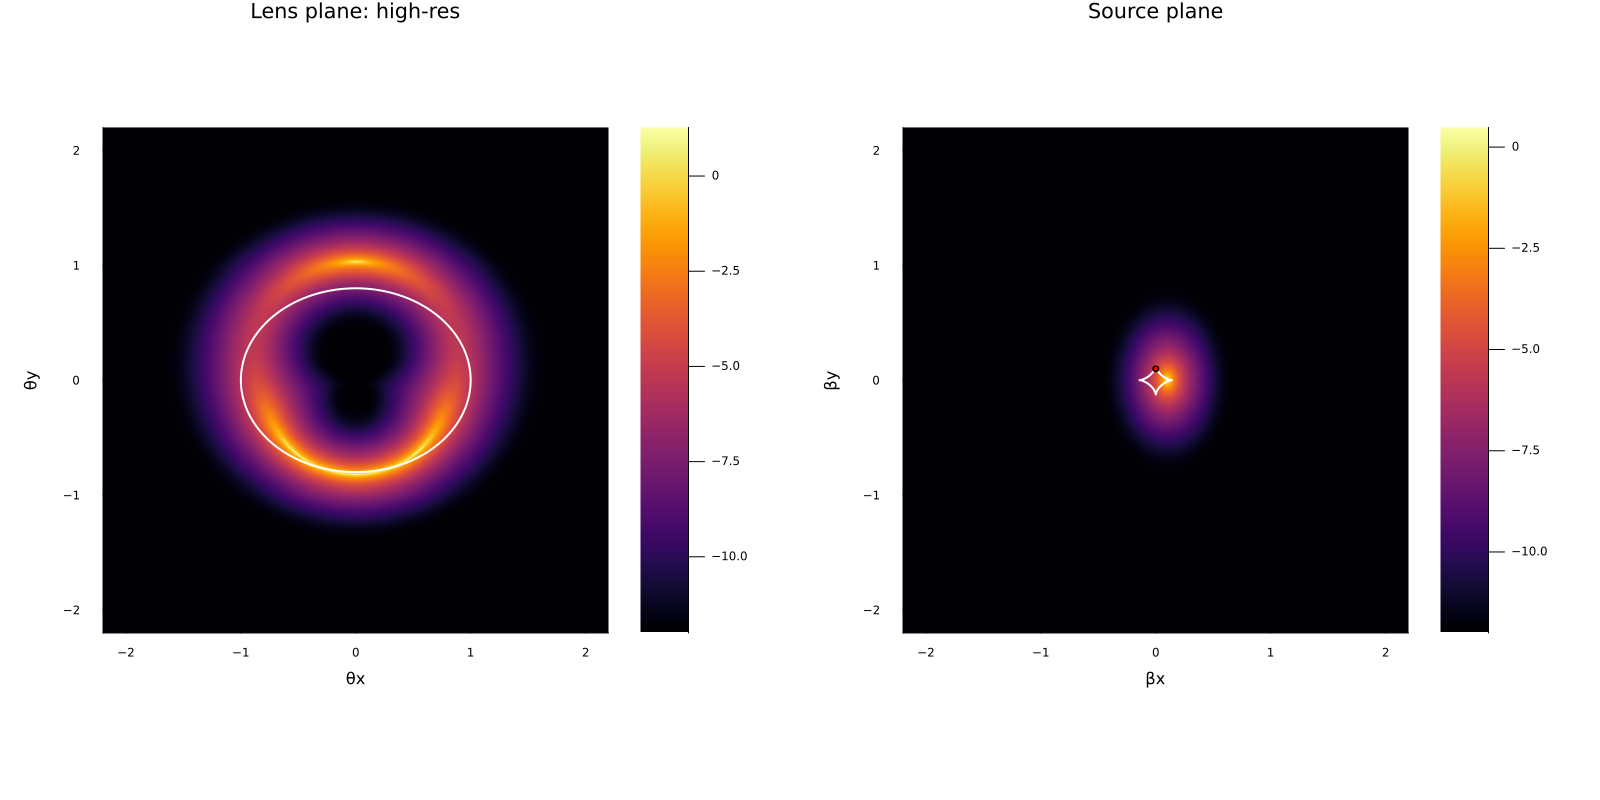

In [10]:
#-------------------------------------------------------------
# Generate the image-plane intensity map I(θ) by ray-shooting.
#
# NOTE: I have also changed the indexing of I from (j,i) to (i,j) as I was getting results that didn't look right to me and this fixes it. I think the original version was transposing the image.
#       Need to verify this is correct and not just masking another issue.
#--------------------------------------------------------------

# lens equation mapping θ -> β 
β_from_θ(lens, θ::SVector{2,Float64}) = θ - deflection(lens, θ)

I_hi  = ray_shoot_intensity_map(lens, src, xs_hi, ys_hi)
I_pix = block_mean(I_hi, os)

# log-stretch for display (guard against ≤0 after noise)
log_stretch(A) = log10.(max.(A, 1.0))

Iplot = log10.(I_pix .+ 1e-12)

p_lens_hi = heatmap(xs_hi, ys_hi, log10.(I_hi .+ 1e-12)';  # log for display
    aspect_ratio=:equal,
    xlims=(xmin, xmax), ylims=(ymin, ymax),
    xlabel="θx", ylabel="θy",
    title="Lens plane: high-res",
    colorbar=true, legend=false
)

for poly in critical_polylines
    plot!(p_lens_hi, first.(poly), last.(poly); lw=2, linecolor=:white)
end

# Unlensed source intensity evaluated directly on the source-plane pixel grid
I_src = [intensity(src, SVector(βx, βy)) for βy in ys_hi, βx in xs_hi]
I_src_plot = log10.(I_src .+ 1e-12)

p_src = heatmap(xs_hi, ys_hi, I_src_plot';
    aspect_ratio=:equal,
    xlims=(xmin, xmax), ylims=(ymin, ymax),
    xlabel="βx", ylabel="βy",
    title="Source plane",
    colorbar=true, legend=false
)

for poly in caustic_polylines
    plot!(p_src, first.(poly), last.(poly); lw=2, linecolor=:white)
end

scatter!(p_src, [β0[1]], [β0[2]]; color=:red, ms=3, label="Source centre")

whole_plot = plot(p_lens_hi, p_src; layout=(1,2), plot_title="", size=(1600, 800), left_margin=12Plots.mm, right_margin=6Plots.mm,
    top_margin=6Plots.mm,   bottom_margin=12Plots.mm)


In [11]:

# ============================================================
#  ANIMATION CONFIGURATION  
# ============================================================

src_params = (I0 = 1.0, Re = Rs, n = 2.0, q = 0.7, ϕ = 0.0)

anim = run_animation(lens, src_params, xs_hi, ys_hi,
                     critical_polylines, caustic_polylines,
                     xmin, xmax, ymin, ymax;
                     β_center          = β0,
                     direction         = (1.0, -1.0),
                     travel_half_width = 0.24,
                     n_frames          = 120,
                     output_file       = "lensq$(lens.q)_srcq$(src_params.q)_βctr$(β0[1])_$(β0[2]).mp4",
                     frame_delay       = 6,
                     fps               = 30, 
                     show_source       = true,
                     show_diff_consec  = true,
                     show_diff_first   = true)

Ray-shooting 120 frames …
  frame 10 / 120
  frame 20 / 120
  frame 30 / 120
  frame 40 / 120
  frame 50 / 120
  frame 60 / 120
  frame 70 / 120
  frame 80 / 120
  frame 90 / 120
  frame 100 / 120
  frame 110 / 120
  frame 120 / 120
Computing unlensed source maps …
Computing global colour scale …
Computing consecutive-frame difference colour scale …
Computing first-frame difference colour scale …
Rendering frames …
  rendering frame 120 / 120
Frame count: 120


[ Info: Saved animation to /home/chrisharhaw/Documents/Optical_Drift_Effects/scripts/lensq0.8_srcq0.7_βctr0.0_0.1.mp4


Saved MP4 → lensq0.8_srcq0.7_βctr0.0_0.1.mp4


Animation("/tmp/jl_diuj1C", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png"  …  "000111.png", "000112.png", "000113.png", "000114.png", "000115.png", "000116.png", "000117.png", "000118.png", "000119.png", "000120.png"])

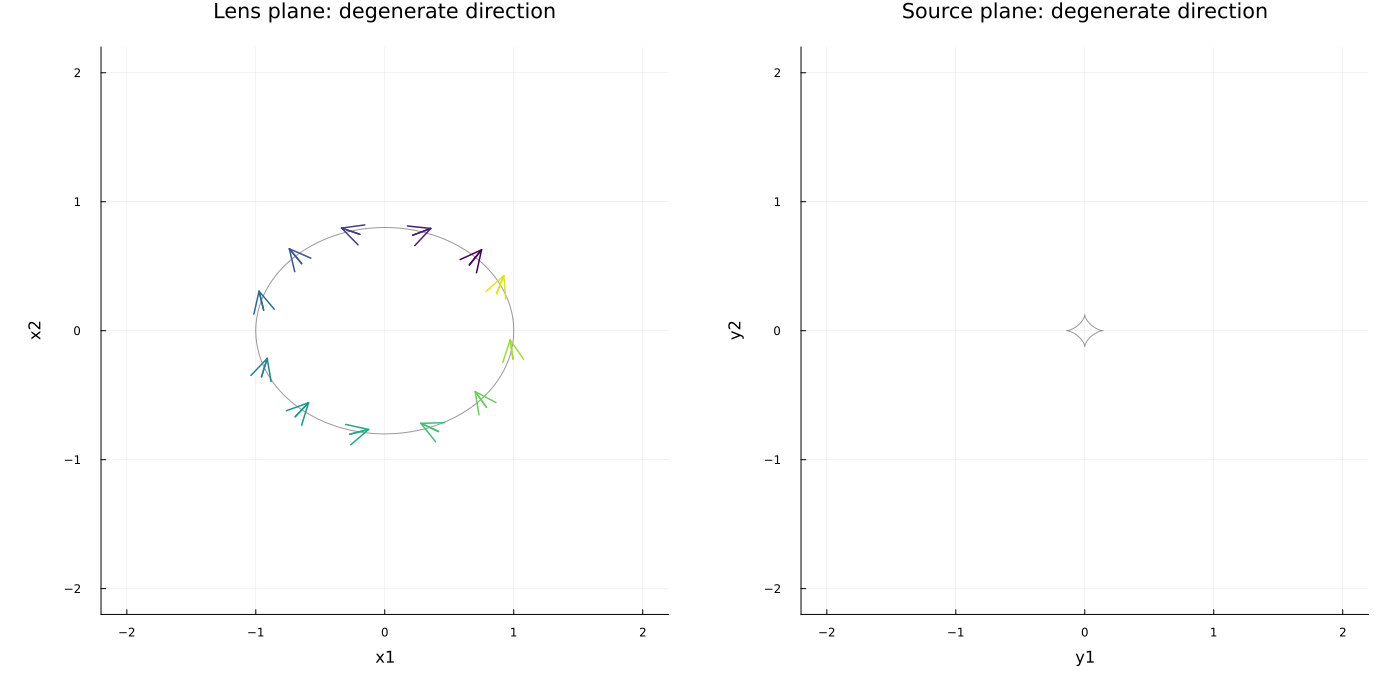

In [12]:
# -----------------------------------------------------------------------
# Visualise the degenerate direction of the Jacobian in both planes.
#
# Note: A*v = 0 by definition (v is the null eigenvector), so the
# degenerate direction cannot be mapped through A in a non-trivial way.
# Instead we draw v at the critical curve point (lens plane) and the
# same vector v at the corresponding caustic point (source plane),
# showing how the merging direction sits in each plane.
#
# Null eigenvector in global frame: v proportional to (-A12, A11)
# -----------------------------------------------------------------------

every      = 70
scale      = 0.15

p_crit  = plot(; aspect_ratio=:equal, xlims=(xmin, xmax), ylims=(ymin, ymax),
                xlabel="x1", ylabel="x2",
                title="Lens plane: degenerate direction",
                legend=false, size=(700,700))

p_caust = plot(; aspect_ratio=:equal, xlims=(xmin, xmax), ylims=(ymin, ymax),
                xlabel="y1", ylabel="y2",
                title="Source plane: degenerate direction",
                legend=false, size=(700,700))

for (crit_poly, caust_poly) in zip(critical_polylines, caustic_polylines)
    n = length(crit_poly)

    plot!(p_crit,  first.(crit_poly),  last.(crit_poly);  lw=1, color=:black, alpha=0.4)
    plot!(p_caust, first.(caust_poly), last.(caust_poly); lw=1, color=:black, alpha=0.4)

    # Arc-length parameter for colouring
    arc = cumsum([0.0; [norm(SVector(crit_poly[i][1]-crit_poly[i-1][1],
                                    crit_poly[i][2]-crit_poly[i-1][2]))
                        for i in 2:n]])
    arc ./= arc[end]

    for i in 1:every:n
        theta_c = SVector(crit_poly[i][1],  crit_poly[i][2])
        y_c     = SVector(caust_poly[i][1], caust_poly[i][2])
        col     = cgrad(:viridis)[arc[i]]

        # Null eigenvector of A: v proportional to (-A12, A11)
        A = deflection_jacobian(lens, theta_c)
        v = SVector(-A[1,2], A[1,1])
        v = v / norm(v)

        # Draw v centred on the critical curve point (lens plane)
        quiver!(p_crit,
                [theta_c[1] - 0.5scale*v[1]],
                [theta_c[2] - 0.5scale*v[2]],
                quiver=([scale*v[1]], [scale*v[2]]);
                color=col, lw=1.5)

        # Draw the same v centred on the caustic point (source plane)
        # A*v = 0 so v is drawn at the caustic location without transformation
        # quiver!(p_caust,
        #         [y_c[1] - 0.5scale*v[1]],
        #         [y_c[2] - 0.5scale*v[2]],
        #         quiver=([scale*v[1]], [scale*v[2]]);
        #         color=col, lw=1.5)
    end
end

plot(p_crit, p_caust; layout=(1,2), size=(1400,700),
     left_margin=12Plots.mm, right_margin=6Plots.mm,
     top_margin=6Plots.mm,   bottom_margin=12Plots.mm)

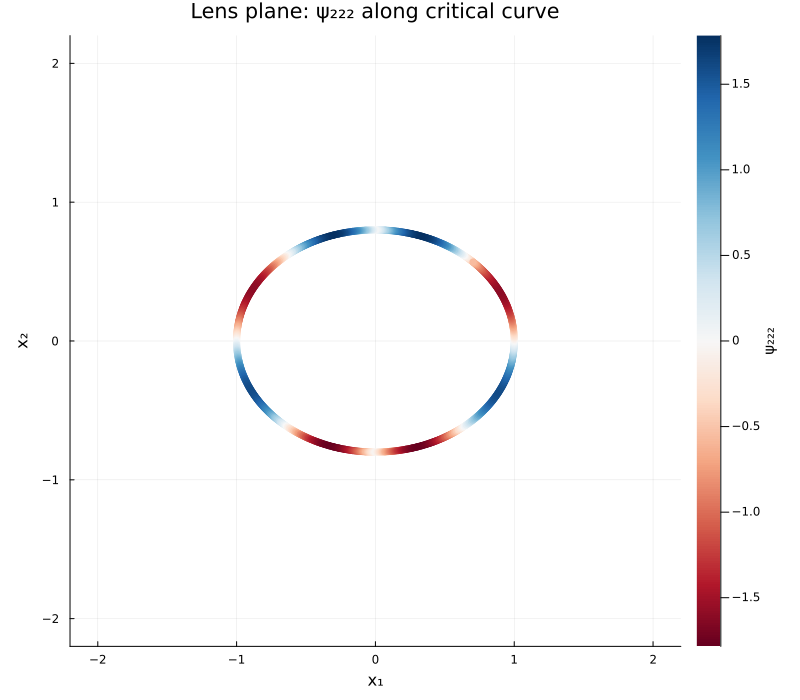

In [13]:
# -----------------------------------------------------------------------
# Visualise the psi_222 quantity along the critical curve
# --------------------------------------------------------------------------

# --- 1. Collect all points and their psi_222 values --------------------
all_x1    = Float64[]
all_x2    = Float64[]
all_ψ222  = Float64[]

for crit_poly in critical_polylines
    for pt in crit_poly
        θ = SVector(pt[1], pt[2])
        Ψ = fold_Psi(lens, θ)
        push!(all_x1,   θ[1])
        push!(all_x2,   θ[2])
        push!(all_ψ222, Ψ[2, 2, 2])
    end
end

vmin, vmax = extrema(all_ψ222)
cmap = cgrad(:RdBu)

vmin, vmax = extrema(all_ψ222)

p_psi = scatter(
    all_x1, all_x2;
    marker_z         = all_ψ222,
    color            = :RdBu,
    clims            = (vmin, vmax),
    colorbar         = true,
    colorbar_title   = "ψ₂₂₂",
    aspect_ratio     = :equal,
    xlims            = (xmin, xmax),
    ylims            = (ymin, ymax),
    xlabel           = "x₁",
    ylabel           = "x₂",
    title            = "Lens plane: ψ₂₂₂ along critical curve",
    legend           = false,
    ms               = 4,
    markerstrokewidth= 0,
    size             = (800, 700),
)

savefig(p_psi, "../plots/psi222_critical_curve.png")

p_psi

In [14]:
# -----------------------------------------------------------------------
# Fold image positions in normal (local) coordinates
#
# Given a source y_s near a fold point x_c, in local coords:
#   du = M(x_c) * (y_s - y_c)
#
# Fold lens equation:
#   du_2 = -1/2 Psi_222 dtheta_2^2
#   du_1 =  lambda_+ dtheta_1 - 1/2 Psi_122 dtheta_2^2
#
# Inversion:
#   dtheta_2 = +/- sqrt(-2 du_2 / Psi_222)
#   dtheta_1 = (du_1 + 1/2 Psi_122 dtheta_2^2) / lambda_+
# -----------------------------------------------------------------------

function fold_image_positions(y_s::AbstractVector, x_c::AbstractVector, lens::SIE)
    theta_c = SVector(Float64(x_c[1]), Float64(x_c[2]))

    # Caustic point
    y_c = theta_c - deflection(lens, theta_c)

    # Local-frame source offset
    M  = ckn_M(lens, theta_c)
    du = M * (SVector(Float64(y_s[1]), Float64(y_s[2])) - y_c)

    # Non-zero eigenvalue of the magnification matrix at x_c:
    # lambda_+ = trace(A) because the other eigenvalue is 0 at the critical curve.
    # deflection_jacobian diagonal entries are 1 - psi_ii, so trace = A[1,1]+A[2,2].
    A_c        = deflection_jacobian(lens, theta_c)
    lambda_plus = A_c[1,1] + A_c[2,2]   # trace = sum of eigenvalues; one is 0

    # Third-derivative tensor in local frame
    Psi    = fold_Psi(lens, theta_c)
    Psi222 = Psi[2,2,2]
    Psi122 = Psi[1,2,2]

    disc = -2du[2] / Psi222
    disc < 0 && return SVector{2,Float64}[]   # source outside fold

    images = SVector{2,Float64}[]
    for sgn in (+1.0, -1.0)
        dt2   = sgn * sqrt(disc)
        dt1   = (du[1] + 0.5 * Psi122 * dt2^2) / lambda_plus
        x_img = theta_c + M' * SVector(dt1, dt2)
        push!(images, x_img)
    end
    return images
end

# Test: nudge a source just inside the caustic along the null direction
test_crit  = critical_polylines[1][100]
test_caust = caustic_polylines[1][100]

M_test  = ckn_M(lens, SVector(test_crit[1], test_crit[2]))
Psi_test = fold_Psi(lens, SVector(test_crit[1], test_crit[2]))
epsilon = 0.005
# The fold images exist when -du2/Psi222 > 0, i.e. du2 and Psi222 have opposite signs.
# Nudge the source in the direction that satisfies this: -sign(Psi222) in u2.
inside_dir = -sign(Psi_test[2,2,2])
y_test  = test_caust + inside_dir * epsilon * SVector(M_test[2,1], M_test[2,2])

imgs = fold_image_positions(y_test, test_crit, lens)
println("Fold image positions (normal-form approximation):")
for (i, img) in enumerate(imgs)
    println("  image ", i, ": x = ", round.(img; digits=6))
end

Fold image positions (normal-form approximation):
  image 1: x = [-0.064708, 0.819645]
  image 2: x = [0.198709, 0.797811]
